# Chapitre evaluation - ablation pgvector vs graphe Neo4j

Ce notebook produit les resultats empiriques utilises dans le chapitre d'evaluation. Le protocole compare deux configurations sur le meme echantillon de candidats :

- `pgvector_only` : classement conserve depuis la recherche semantique pgvector ;
- `pgvector_plus_graph` : meme pool initial pgvector, puis enrichissement Neo4j et reranking par score hybride.

La generation LLM est volontairement exclue afin de mesurer l'effet du graphe sur le retrieval/reranking, sans melanger cette mesure avec la qualite de redaction du modele.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / 'src' / '07_evaluation'))

from ablation_pgvector_graph import EvalConfig, run_ablation

print(ROOT)

D:\DATA SCIENCES\SYSTEME-DE-RECOMMANDATION-HYBRIDE-


## Execution du protocole

Parametres retenus : 60 candidats tires aleatoirement, 30 offres candidates par candidat issues de pgvector, evaluation finale a K=10. Ce choix limite le temps d'execution tout en conservant assez d'observations pour comparer les deux configurations.

In [2]:
summary = run_ablation(EvalConfig(n_candidats=60, candidate_pool_k=30, final_k=10, random_seed=42))
print(json.dumps(summary, ensure_ascii=False, indent=2))

D:\DATA SCIENCES\SYSTEME-DE-RECOMMANDATION-HYBRIDE-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


09:21:35  INFO     No device provided, using cpu


09:21:35  INFO     Loading SentenceTransformer model from D:\DATA SCIENCES\SYSTEME-DE-RECOMMANDATION-HYBRIDE-\models\st_finetuned\final.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3364.46it/s]

{
  "config": {
    "n_candidats": 60,
    "candidate_pool_k": 30,
    "final_k": 10,
    "random_seed": 42
  },
  "elapsed_s": 38.7,
  "n_queries_requested": 60,
  "n_queries_evaluated": 55,
  "n_errors": 5,
  "metrics": [
    {
      "system": "pgvector_only",
      "n_queries": 55,
      "n_relevant_in_pool": 6.3273,
      "precision@1": 0.4182,
      "recall@1": 0.1073,
      "ndcg@1": 0.4182,
      "mrr@1": 0.4182,
      "hit_rate@1": 0.4182,
      "precision@3": 0.2788,
      "recall@3": 0.2224,
      "ndcg@3": 0.3588,
      "mrr@3": 0.5152,
      "hit_rate@3": 0.6364,
      "precision@5": 0.2509,
      "recall@5": 0.2821,
      "ndcg@5": 0.355,
      "mrr@5": 0.5324,
      "hit_rate@5": 0.7091,
      "precision@10": 0.2382,
      "recall@10": 0.4599,
      "ndcg@10": 0.3889,
      "mrr@10": 0.5602,
      "hit_rate@10": 0.9273
    },
    {
      "system": "pgvector_plus_graph",
      "n_queries": 55,
      "n_relevant_in_pool": 6.3273,
      "precision@1": 0.3636,
      "recall@1

In [3]:
import pandas as pd

out_dir = ROOT / summary['outputs_dir']
metrics = pd.read_csv(out_dir / 'ablation_metrics.csv')
per_query = pd.read_csv(out_dir / 'ablation_per_query.csv')
details = pd.read_csv(out_dir / 'ablation_graph_rerank_details.csv')

metrics

,system,n_queries,n_relevant_in_pool,precision@1,recall@1,ndcg@1,mrr@1,hit_rate@1,precision@3,recall@3,...,precision@5,recall@5,ndcg@5,mrr@5,hit_rate@5,precision@10,recall@10,ndcg@10,mrr@10,hit_rate@10
0,pgvector_only,55,6.3273,0.4182,0.1073,0.4182,0.4182,0.4182,0.2788,0.2224,...,0.2509,0.2821,0.3550,0.5324,0.7091,0.2382,0.4599,0.3889,0.5602,0.9273
1,pgvector_plus_graph,55,6.3273,0.3636,0.1446,0.3636,0.3636,0.3636,0.2970,0.2249,...,0.3091,0.3284,0.4016,0.4442,0.6182,0.3145,0.5557,0.4681,0.4647,0.7818


In [4]:
delta = pd.DataFrame([
    {'metric': metric, 'delta_graph_minus_pgvector': value}
    for metric, value in summary['delta_pgvector_plus_graph_minus_pgvector'].items()
])
delta.sort_values('metric')

,metric,delta_graph_minus_pgvector
5,hit_rate@1,-0.0546
20,hit_rate@10,-0.1455
10,hit_rate@3,-0.1455
15,hit_rate@5,-0.0909
4,mrr@1,-0.0546
19,mrr@10,-0.0955
9,mrr@3,-0.1000
14,mrr@5,-0.0882
0,n_relevant_in_pool,0.0000
3,ndcg@1,-0.0546


## Figures exportees

Les figures sont exportees dans `outputs/evaluation/pgvector_vs_graph` pour audit et dans `rapport/figures/generated/evaluation` pour inclusion dans le memoire.

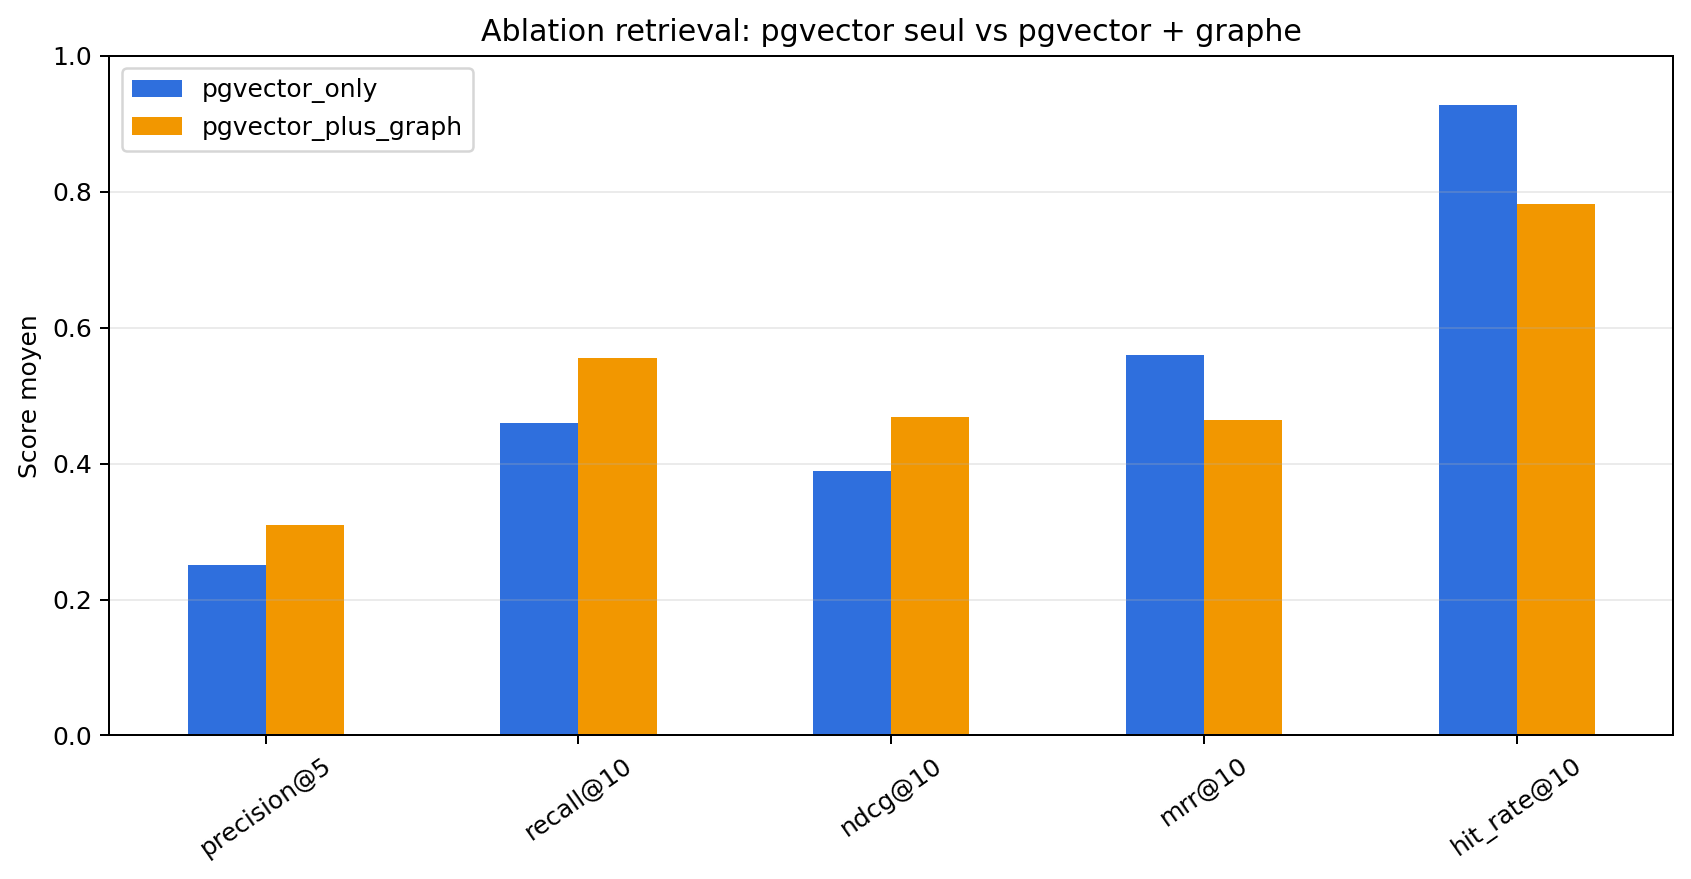

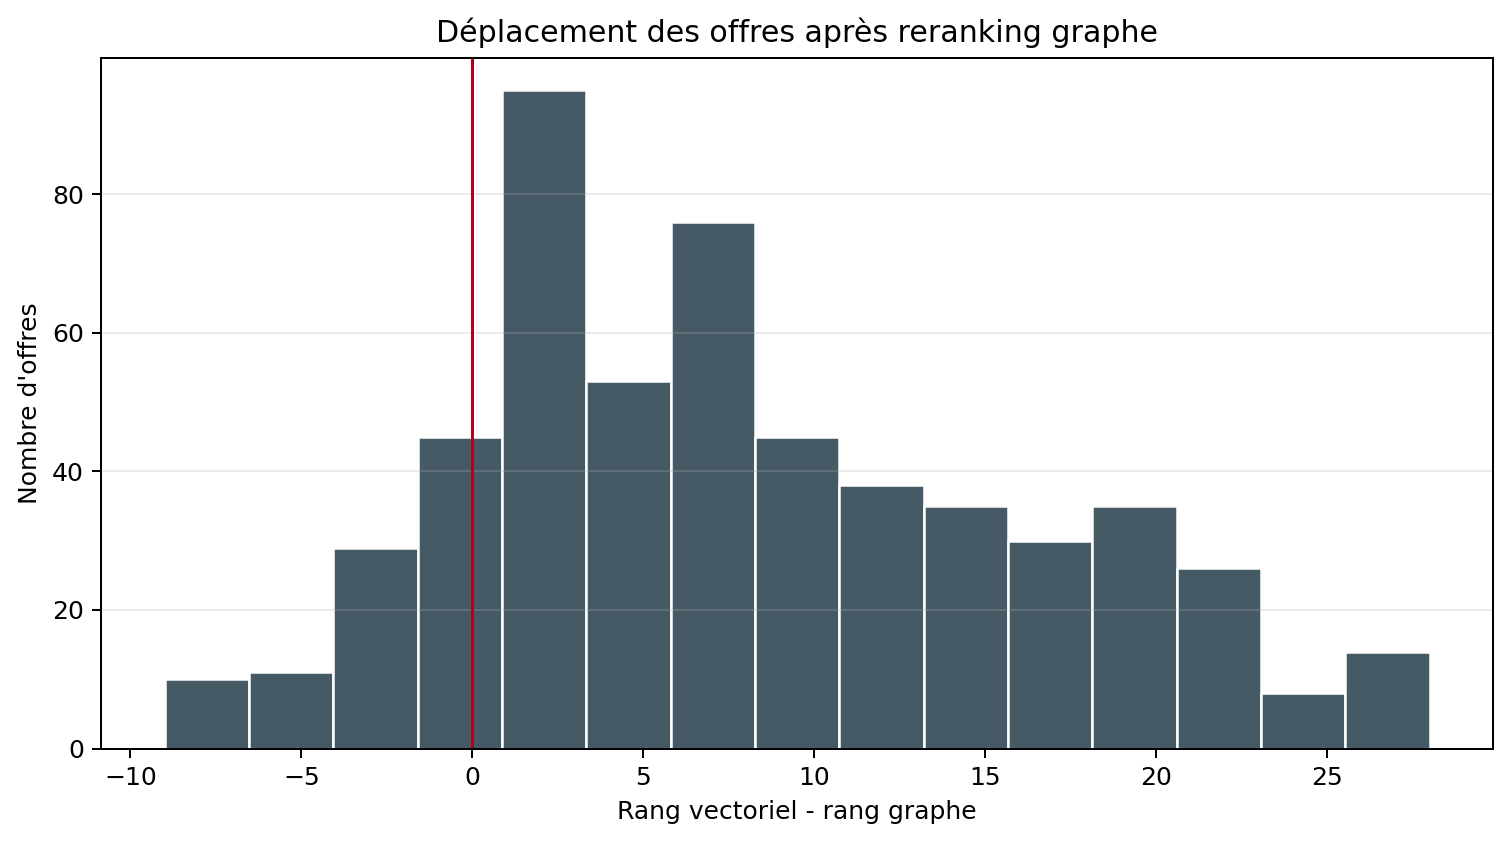

In [5]:
from IPython.display import Image, display

fig_dir = ROOT / summary['figures_dir']
display(Image(filename=str(fig_dir / 'ablation_metrics_comparison.png')))
display(Image(filename=str(fig_dir / 'graph_rerank_rank_shift.png')))

## Limite methodologique

La pertinence utilisee pour calculer les metriques n'est pas une annotation humaine. Elle est definie comme un proxy a partir des metadonnees normalisees : chevauchement lexical metier/competences, proximite sectorielle et compatibilite de niveau NCF. Les scores doivent donc etre interpretes comme une evaluation comparative interne de l'effet du graphe, non comme une mesure definitive de satisfaction utilisateur.